In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("PrePlacement.csv")

In [3]:
dataset

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,gender,ssc_b,hsc_b,hsc_s,degree_t,workex,specialisation,status
0,1.0,67.00,91.00,58.00,55.0,58.80,270000.000000,M,Others,Others,Commerce,Sci&Tech,No,Mkt&HR,Placed
1,2.0,79.33,78.33,77.48,86.5,66.28,200000.000000,M,Central,Others,Science,Sci&Tech,Yes,Mkt&Fin,Placed
2,3.0,65.00,68.00,64.00,75.0,57.80,250000.000000,M,Central,Central,Arts,Comm&Mgmt,No,Mkt&Fin,Placed
3,4.0,56.00,52.00,52.00,66.0,59.43,288655.405405,M,Central,Central,Science,Sci&Tech,No,Mkt&HR,Not Placed
4,5.0,85.80,73.60,73.30,96.8,55.50,425000.000000,M,Central,Central,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211.0,80.60,82.00,77.60,91.0,74.49,400000.000000,M,Others,Others,Commerce,Comm&Mgmt,No,Mkt&Fin,Placed
211,212.0,58.00,60.00,72.00,74.0,53.62,275000.000000,M,Others,Others,Science,Sci&Tech,No,Mkt&Fin,Placed
212,213.0,67.00,67.00,73.00,59.0,69.72,295000.000000,M,Others,Others,Commerce,Comm&Mgmt,Yes,Mkt&Fin,Placed
213,214.0,74.00,66.00,58.00,70.0,60.23,204000.000000,F,Others,Others,Commerce,Comm&Mgmt,No,Mkt&HR,Placed


In [4]:
#Now check for nan values 
dataset.isnull().sum()

sl_no             0
ssc_p             0
hsc_p             0
degree_p          0
etest_p           0
mba_p             0
salary            0
gender            0
ssc_b             0
hsc_b             0
hsc_s             0
degree_t          0
workex            0
specialisation    0
status            0
dtype: int64

#Now plot normal distripution curve using seaborn 

In [5]:
#!pip install seaborn
#import seaborn as sns #(ModuleNotFoundError: No module named 'seaborn')

In [6]:
import seaborn as sns

C:\Anaconda3\envs\aiml\lib\site-packages\ipykernel_launcher.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  """Entry point for launching an IPython kernel.


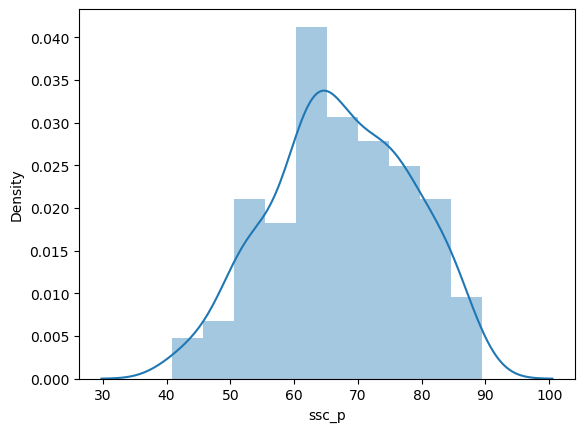

In [7]:
sns.distplot(dataset["ssc_p"])

In [8]:
#the barchat is histogram and curve is normal distribution curve.

Now we have normal distibution curve and histogram for column ssc_p ploted.
we have to plot pdf 

In [9]:
def get_pdf_probability(dataset,startrange,endrange): #(make function for future use)
    from matplotlib import pyplot   #(import matplotlib library for handling diagram)
    from scipy.stats import norm    #(import norm to plaot narmal distribution curve)
    import seaborn as sns
    #(kernel density=true,this function from seaborn used to plot curve)
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green') 
    #then, the following code created for ploting vertical line with red colour
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    # generate a sample
    sample = dataset #(assing dataset to sample variable)
    # calculate parameters
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # define the distribution
    dist = norm(sample_mean, sample_std) 
    # sample probabilities for a range of outcomes
    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]    
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob

Mean=67.303, Standard Deviation=10.827
The area between range(40,60):0.23035961179550077


C:\Anaconda3\envs\aiml\lib\site-packages\ipykernel_launcher.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  


0.23035961179550077

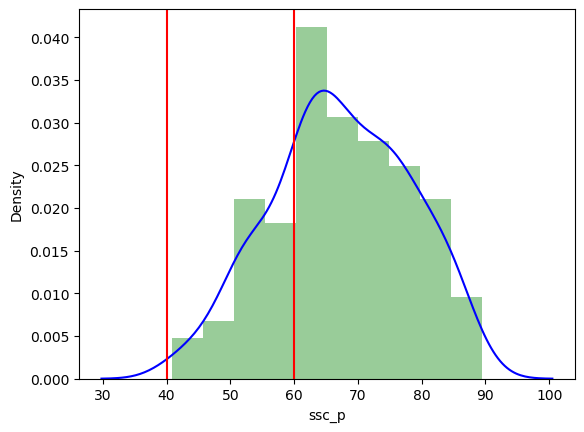

In [10]:
get_pdf_probability(dataset["ssc_p"],40,60)

In [11]:
values=[]
for value in range(1,4):
    values.append(value)
    print(values)

[1]
[1, 2]
[1, 2, 3]


#lets re-create the following code with traditional method.

In [12]:
#values = [value for value in range(startrange, endrange)]
#probabilities = [dist.pdf(value) for value in values]    
#prob=sum(probabilities)
def tra_pdf_calculator(dataset,startrange,endrange):
    from matplotlib import pyplot   
    from scipy.stats import norm    
    import seaborn as sns
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green') 
    #then, the following code created for ploting vertical line with red colour
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    # generate a sample
    sample = dataset #(assing dataset to sample variable)
    # calculate parameters
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # define the distribution
    dist = norm(sample_mean, sample_std) 
    # sample probabilities for a range of outcomes
    values=[]
    probabilities=[]
    for value in range(startrange,endrange):
        values.append(value)
        probabilities.append(dist.pdf(value))
    #values = [value for value in range(startrange, endrange)]
    #probabilities = [dist.pdf(value) for value in values]    
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob

Mean=67.303, Standard Deviation=10.827
The area between range(56,77):0.664518247929439


C:\Anaconda3\envs\aiml\lib\site-packages\ipykernel_launcher.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  


0.664518247929439

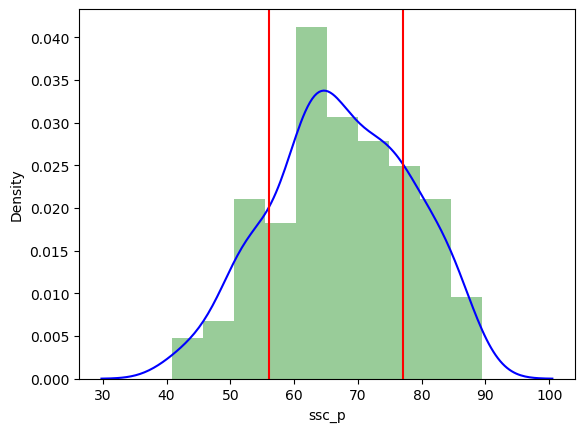

In [13]:
tra_pdf_calculator(dataset["ssc_p"],56,77) 

In [14]:
import numpy as np
np.percentile(dataset["ssc_p"],100)

89.4

In [15]:
from statsmodels.distributions.empirical_distribution import ECDF  #find cumulative density function
ecdf = ECDF(dataset['ssc_p'])
ecdf(89.4)

1.0

In [16]:
def std_nb_plot(dataset): # Coverted to standard Normal Distribution
    
    import seaborn as sns
    mean=dataset.mean()
    std=dataset.std()

    values=[i for i in dataset]   #we pass dataset to convert as list so,we can take any column for output

    z_score=[((j-mean)/std) for j in values]  #we know formulae z_score= (x-mean / std)

    sns.distplot(z_score,kde=True) #now plot z_score distribution 

    sum(z_score)/len(z_score)
    return z_score
   

C:\Anaconda3\envs\aiml\lib\site-packages\ipykernel_launcher.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  # This is added back by InteractiveShellApp.init_path()


[-0.02802157506744731,
 1.1107764385006722,
 -0.21274144750347646,
 -1.0439808734656075,
 1.7083452258312264,
 -1.136340809683622,
 -1.9675802356457532,
 1.3573774682027713,
 0.5261380422406401,
 -0.8592610010295785,
 -0.8592610010295785,
 0.21211425909939005,
 -1.8752202994277387,
 0.8955777871126984,
 -0.48982125615752015,
 -0.21274144750347646,
 -0.3974613199395056,
 -1.136340809683622,
 -0.3974613199395056,
 -0.6745411285935493,
 -0.48982125615752015,
 1.0802976595487275,
 0.2305862463429932,
 0.9325217615999047,
 0.8493978190036912,
 -1.3598518553312176,
 0.341418169804611,
 -0.3974613199395056,
 0.8734114024203754,
 -0.48982125615752015,
 -0.30510138372149104,
 -0.02802157506744731,
 -0.5821811923755348,
 1.8191771492928441,
 -0.48982125615752015,
 0.15669829736858182,
 -1.5057805545556804,
 1.0802976595487275,
 0.5261380422406401,
 1.2650175319847567,
 0.987937723330713,
 0.6184979784586547,
 -1.6905004269917097,
 1.8191771492928441,
 0.8955777871126984,
 0.8032178508946838,
 0.

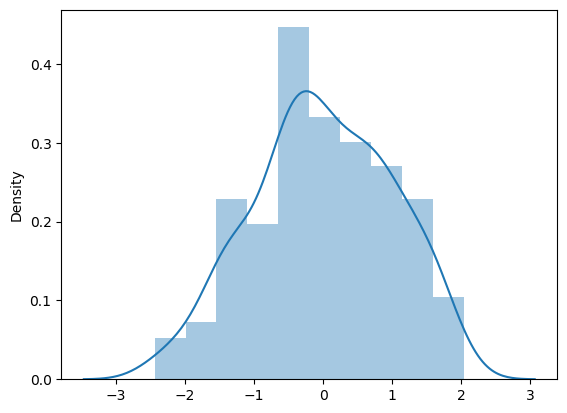

In [17]:
std_nb_plot(dataset["ssc_p"])


C:\Anaconda3\envs\aiml\lib\site-packages\ipykernel_launcher.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  # This is added back by InteractiveShellApp.init_path()


[-0.24084574176230647,
 -1.1445624692731684,
 -0.4990505210511242,
 -7.514748119540096e-16,
 1.7602412977260307,
 -7.514748119540096e-16,
 -7.514748119540096e-16,
 -0.47323004312224237,
 -0.7443450613755009,
 -7.514748119540096e-16,
 -0.3699481314067153,
 -0.4990505210511242,
 -7.514748119540096e-16,
 -0.9121781679132325,
 -7.514748119540096e-16,
 -1.1445624692731684,
 0.1464614271709201,
 -7.514748119540096e-16,
 -7.514748119540096e-16,
 -0.6797938665532965,
 -0.3053969365845109,
 1.3471136508639223,
 0.9210757650373732,
 0.1464614271709201,
 0.9210757650373732,
 -7.514748119540096e-16,
 -0.628152910695533,
 -0.3053969365845109,
 0.7919733753929643,
 -7.514748119540096e-16,
 -0.4990505210511242,
 -7.514748119540096e-16,
 -0.13756383004677938,
 -0.3699481314067153,
 -7.514748119540096e-16,
 0.1464614271709201,
 -7.514748119540096e-16,
 0.4046662064597378,
 -0.628152910695533,
 1.5794979522238584,
 -0.021371679366811412,
 -7.514748119540096e-16,
 -7.514748119540096e-16,
 0.1464614271709

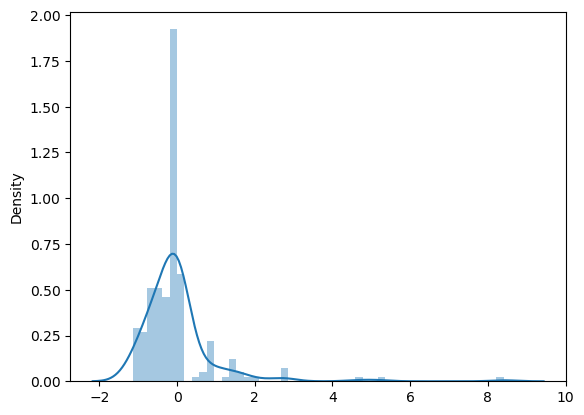

In [18]:
std_nb_plot(dataset["salary"])

In [19]:
#let's find what if categorical column?
#std_nb_plot(dataset["genter"]) KeyError: 'genter'